# Tutorials

Here we present examples on how to Nimbus can be used. If you would like to use Nimbus for a case not demonstrated here, please contact Sven Kiefer (kiefersv.mail@gmail.com).


## Clouds on top of an Atmospheric Model

Nimbus can be used to calculate cloud structures based on atmospheric models. Here we show the example of Sonora Diamondback for a cloud structure made from SiO2 and MgSiO3.

In [1]:
import numpy as np
from nimbus import Nimbus

# ==== Default parameters for a gas-giant exoplanet
setup = {
    'M_planet': 1, 'R_planet': 1, 'gravity': 3100, 'mh_planet': 1, 'mmw': 2.34,
    'w_min': 1, 'w_max': 14, 'species': ['SiO2', 'MgSiO3'],
    'gas_mmr_init': [3e-3, 5e-4], 'ignore_as_nucleator': ['MgSiO3']
}

# ==== read in the tp profile
tpname = 'tutorial_files/t1500g316f2_m0.0_co1.0.pt'
tp_profile = np.genfromtxt(tpname, skip_header=2)

# ==== prepare data for Nimbus
setup['pressure_bar'] = tp_profile[:, 1]
setup['temperature'] = tp_profile[:, 2]
setup['kzz'] = 1e10 * np.ones_like(setup['temperature'])

# ==== Set up Nimbus object
nimb = Nimbus(working_dir='working/', verbose=True)

# ==== Set up Nimbus atmosphere structure
nimb.set_up_atmosphere(
    setup['temperature'], setup['pressure_bar'], setup['kzz'], setup['mmw'],
    setup['gravity'], setup['species'], setup['gas_mmr_init'],
    ignore_as_nucleator=setup['ignore_as_nucleator']
)

# ==== run Nimbus
nimb.set_up_solver()
ds = nimb.compute(typ='full')


                   Welcome to Nimbus                       
[INFO] For questions contact: kiefersv.mail@gmail.com
[INFO] Settings selected:
       -> working directory: working/
       -> verbose: True
       -> analytic plots: False
[INFO] Atmosphere set up with:
       -> pressure range: 6.37e+01 - 1.78e-04 bar
       -> temperature range: 3.77e+03 - 7.52e+02 K
       -> Kzz range: 1.00e+10 - 1.00e+10 cm2/s
       -> Mean molecular weight: 2.34e+00 amu
       -> Gravity: 3.10e+03 cm/s2
       -> SiO2 deep MMR: 3.00e-03 g/g
       -> MgSiO3 deep MMR: 5.00e-04 g/g
[INFO] Solver set up.
[INFO] Cloud structures completed in 63.47s (1 iterations).
[INFO] Saved run under tag: last_run


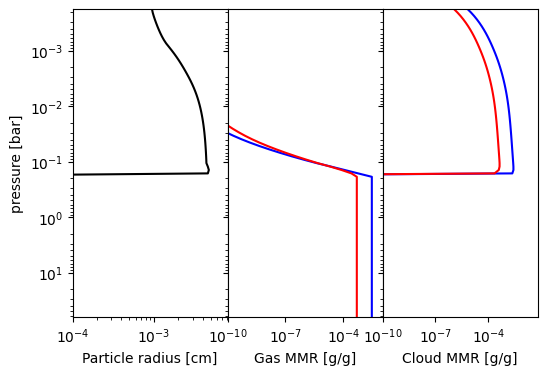

In [2]:
import matplotlib.pyplot as plt

# ==== plot results
fig, ax = plt.subplots(1, 3, figsize=(6,4))
ax[0].plot(ds['cloud_radius'][:-2], ds['pressure'][:-2], color='k')
ax[2].plot(ds['cloud_mmr'][0], ds['pressure'], color='blue')
ax[2].plot(ds['cloud_mmr'][1], ds['pressure'], color='red')
ax[1].plot(ds['gas_mmr'][0], ds['pressure'], color='blue')
ax[1].plot(ds['gas_mmr'][1], ds['pressure'], color='red')

# ==== make the plot pretty
for axi in ax:
    axi.set_ylim(bottom=ds['pressure'][-1], top=ds['pressure'][0])
    axi.set_yscale('log')
    axi.set_xscale('log')
plt.subplots_adjust(wspace=0)
ax[0].set_ylabel('pressure [bar]')
ax[2].set_xlabel('Cloud MMR [g/g]')
ax[1].set_xlabel('Gas MMR [g/g]')
ax[0].set_xlabel('Particle radius [cm]')
ax[1].get_yaxis().set_ticklabels([])
ax[2].get_yaxis().set_ticklabels([])
ax[0].set_xlim(1e-4)
ax[1].set_xlim(1e-10)
ax[2].set_xlim(1e-10)
plt.show()

## Creating a Spectrum

Nimbus is compatible with PICASO which allows to calculate thermal emission and transmission spectra. Here we show how the spectra of the previous example can be calculated. This requires a working installation of both [PICASO](https://github.com/natashabatalha/picaso) and [MieAi](https://github.com/d-attaway/mieai/tree/main/mieai).

In [15]:
import os
import pandas as pd
import astropy.units as u
from picaso import justdoit as jdip

# ==== Calculate opacities and return them in PICASO format
df_cloud = nimb.picaso_formater(mie_type='full')
print(df_cloud)

# ==== Convert temperature structure to PICASO format
d = {
    'pressure': setup['pressure_bar'],
    'temperature': setup['temperature']
}

# ==== Convert chemistry to PICASO format
chem_list = ['H2', 'H', 'VO', 'TiO', 'CO2', 'He', 'H2O', 'CH4', 'CO']
chem = {}
for n, name in enumerate(chem_list):
    d[name] = tp_profile[:, 4+n]

# ==== save everything as a pandas frame
df = pd.DataFrame(data=d)

def spectrum(setup, df, df_cl=None):
    # ==== Create PICASO class and set it up
    opa = jdip.opannection(wave_range=[setup['w_min'], setup['w_max']])
    case1 = jdip.inputs(calculation='browndwarf')
    case1.phase_angle(0)
    case1.gravity(
        mass=setup['M_planet'], mass_unit=u.Unit('M_jup'),
        radius=setup['R_planet'], radius_unit=u.Unit('R_jup')
    )

    # ==== Add clouds and atmospheric structure
    case1.atmosphere(df=df)
    if df_cl is not None:
        case1.clouds(df=df_cl)

    # ==== Calculate emission spectra
    e_df = case1.spectrum(opa, full_output=True, calculation='thermal')

    # ==== Regrid output
    emis_wavn, _, emis_fp = e_df['wavenumber'], e_df['fpfs_thermal'], e_df['thermal']
    emis_wavn_bin, emis_fp_bin = jdip.mean_regrid(emis_wavn, emis_fp, R=400)

    # ==== convert units
    return 1e4/emis_wavn_bin, emis_fp_bin

w_nocloud, e_nocloud = spectrum(setup, df)
w_cloudy, e_cloudy = spectrum(setup, df, df_cloud)

Volume mixing ratios do not add up to 1. The ratios have been renormalized.
Volume mixing ratios do not add up to 1. The ratios have been renormalized.
Volume mixing ratios do not add up to 1. The ratios have been renormalized.
Volume mixing ratios do not add up to 1. The ratios have been renormalized.
            opd        w0        g0      pressure    wavenumber
0      0.000098  0.916337  0.918632  1.785808e-01  37313.432836
1      0.000099  0.934371  0.897802  1.785808e-01  34843.205575
2      0.000099  0.949894  0.880439  1.785808e-01  32051.282051
3      0.000099  0.960790  0.869371  1.785808e-01  29673.590504
4      0.000099  0.916035  0.925001  1.785808e-01  27624.309392
...         ...       ...       ...           ...           ...
17635  0.000000  0.000000  0.000000  7.907528e+11    185.601069
17636  0.000000  0.000000  0.000000  7.907528e+11    135.699940
17637  0.000000  0.000000  0.000000  7.907528e+11    102.299697
17638  0.000000  0.000000  0.000000  7.907528e+11     72

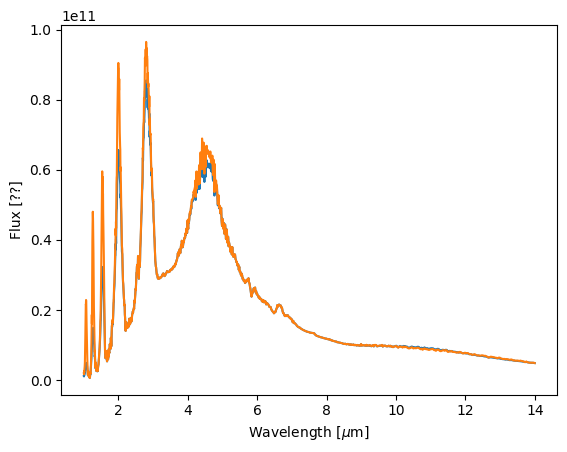

In [16]:
plt.figure()
plt.plot(w_cloudy, e_cloudy)
plt.plot(w_nocloud, e_nocloud)
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel(r'Flux [??]')
plt.show()